# Data Validation

This notebook analyzes the dataset to identify invalid or inconsistent records and assess data quality. 

The findings is used to make informed data-driven decisions on how to handle such records—whether through removal, flagging, imputation, isolation, or other appropriate remediation strategies.

## Workspace Initialization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/ecommerce_customer_churn_dataset.csv')
df.shape

(50000, 25)

In [3]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

---

## Identify Suspecious Columns
This section identifies the suspecious columns in that hold invalid values.

### All Columns

In [4]:
missing_counts = df.isna().sum()

# columns missing values less than 1%
result = missing_counts[missing_counts.between(1, 500)]
print('missingness <1%:')
print(result)

missingness <1%:
Customer_Service_Calls    168
dtype: int64


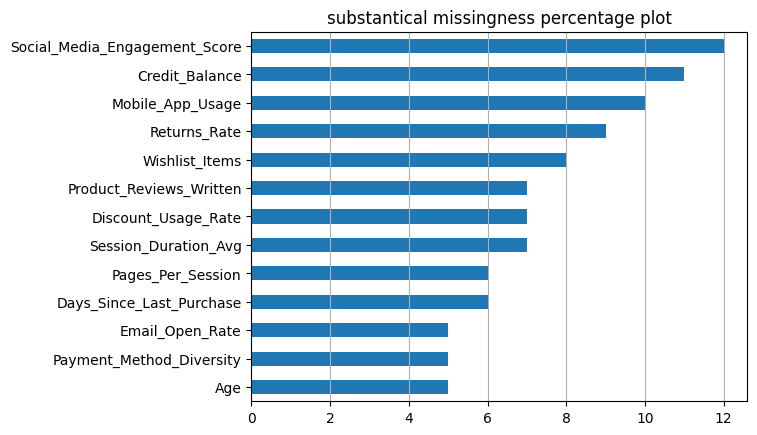

In [5]:
# missing values by percentage
missing_pct = (missing_counts.sort_values() / 500).round(0)
missing_pct = missing_pct[missing_pct > 0]   # keep only > 0

missing_pct.plot(kind='barh')
plt.grid(visible=True, which='both', axis='x')
plt.title('substantical missingness percentage plot')
plt.show()

In [6]:
print(f"{df.isna().any(axis=1).sum()} records out of {df.shape[0]} in dataset with one or more missingness")

32017 records out of 50000 in dataset with one or more missingness


In [7]:
# schema/type check

summary = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.values,
    "nunique": df.nunique().values})\
        .sort_values(["dtype", "nunique"], ascending=[True, True])\
        .set_index(["dtype", "feature"])

summary

nunique
dtype   feature                               
int64   Churned                              2
float64 Payment_Method_Diversity             5
        Product_Reviews_Written             18
        Customer_Service_Calls              21
        Wishlist_Items                      25
        Login_Frequency                     46
        Age                                 62
        Total_Purchases                    150
        Membership_Years                   200
        Pages_Per_Session                  224
        Days_Since_Last_Purchase           235
        Returns_Rate                       394
        Mobile_App_Usage                   540
        Session_Duration_Avg               658
        Email_Open_Rate                    720
        Social_Media_Engagement_Score      972
        Cart_Abandonment_Rate             1000
        Discount_Usage_Rate               1727
        Credit_Balance                    5234
        Average_Order_Value              16407
        Lifetime_Value                   45447
object  Gender                               3
        Signup_Quarter                       4
        Country                              8
        City                                40

In [8]:
# duplicate records check
print('no of duplicate records:', df.duplicated().sum())

no of duplicate records: 0


Remarks:
* `Customer_Service_Calls` is the only column with missing values under 1% (168 records, ~0.34% of dataset), so this column alone has low impact size.
* Missingness is concentrated in a subset of numeric behavioural columns with 5% or more records.
* 32,017 records out of 50,000 contain one or more missing values, therefore missingness is a dataset-level concern and needs structured handling in later stages.
* `Churned` is a binary column, while `Payment_Method_Diversity`(5), `Product_Reviews_Written`(18), `Customer_Service_Calls`(21), `Wishlist_Items`(25) are low cardinality columns. Rest of numeric columns are mid to high cardinality. 
* No duplicate records found in dataset, and dtype structure looks aligned with feature meaning. They won't be concern at this stage.

### Categorical Columns Only

In [9]:
df.describe(include=object)

,Gender,Country,City,Signup_Quarter
count,50000,50000,50000,50000
unique,3,8,40,4
top,Female,USA,Houston,Q3
freq,25116,17384,3549,12558


In [10]:
cat_cols = df.select_dtypes(object).columns
df[cat_cols].nunique()

Gender             3
Country            8
City              40
Signup_Quarter     4
dtype: int64

In [11]:
[df[col].unique() for col in cat_cols]

[array(['Male', 'Female', 'Other'], dtype=object),
 array(['France', 'UK', 'Canada', 'USA', 'India', 'Japan', 'Germany',
        'Australia'], dtype=object),
 array(['Marseille', 'Manchester', 'Vancouver', 'New York', 'Delhi',
        'Tokyo', 'Berlin', 'Houston', 'Calgary', 'Glasgow', 'Munich',
        'Phoenix', 'Paris', 'Ottawa', 'Los Angeles', 'Bangalore',
        'Adelaide', 'Yokohama', 'Sydney', 'Nagoya', 'Frankfurt', 'Cologne',
        'Hamburg', 'Nice', 'Chicago', 'Toulouse', 'Brisbane', 'Leeds',
        'Mumbai', 'Montreal', 'Melbourne', 'Osaka', 'Lyon', 'Hyderabad',
        'Chennai', 'Birmingham', 'London', 'Toronto', 'Perth', 'Kyoto'],
       dtype=object),
 array(['Q1', 'Q4', 'Q2', 'Q3'], dtype=object)]

Remarks:
* `Gender`: Other attribute can be indication of 'prefer not to say' or customer never provided gender info. 
* Rest 3 columns have valid city and country names, valid quarter terminology.
* `City` is like a subcategory of `Country` column, and skips the validation of city subclasses belongs to right country class or not. 

### Numeric Columns Only

In [12]:
pd.DataFrame({
    'min': df.select_dtypes(float).min(),
    'max': df.select_dtypes(float).max()  
})

,min,max
Age,5.00,200.000000
Membership_Years,0.10,10.000000
Login_Frequency,0.00,46.000000
Session_Duration_Avg,1.00,75.600000
Pages_Per_Session,1.00,24.100000
Cart_Abandonment_Rate,0.00,143.743350
Wishlist_Items,0.00,28.000000
Total_Purchases,-13.00,128.700000
Average_Order_Value,26.38,9666.379178
Days_Since_Last_Purchase,0.00,287.000000


Suspecious columns `min` stats:
* **KEEP** `Login_Frequency` (Average number of logins per month) is 0: User must have login atleast 1 time in the life, or the first login was through signup which are not considered in this variable. **ASSUMED** the later one.
* **FURTHER ANALYSE** `Total_Purchases` (Total number of purchases made) is -ve:  customers have more return orders where business incurr loss over revenue, or data collection error.
* **KEEP** `Mobile_App_Usage` (Percentage of activity via mobile app) is 0: Customer may have different mode of access to service, example website, telecalls, sms/whatsapp. 
* **FURTHER ANALYSE** `Lifetime_Value` (Total customer lifetime value in currency units): No purchase so far, or computation error.
* **FURTHER ANALYSE** `Discount_Usage_Rate` (Percentage of purchases using discounts): Customer can not have more than 100% order purchase where discount used. 

Suspecious Columns `max` stats:
* **FURTHER ANALYSE** `Age` (Customer's age in years) is > 100: data collection error
* **FURTHER ANALYSE** `Average_Order_Value` (Average over value per month) is too high: Its more suspicious when looked along with ltv. Can be geniune but too rare.

In [13]:
# data skewness on high cardinality columns
df.loc[:, df.nunique() > 30].skew(numeric_only=True).sort_values()

Cart_Abandonment_Rate            -0.263285
Discount_Usage_Rate               0.369334
Credit_Balance                    0.377993
Pages_Per_Session                 0.390680
Session_Duration_Avg              0.400619
Mobile_App_Usage                  0.404941
Email_Open_Rate                   0.493762
Social_Media_Engagement_Score     0.504877
Login_Frequency                   0.511945
Age                               0.946678
Membership_Years                  1.136922
Lifetime_Value                    1.447403
Days_Since_Last_Purchase          1.991117
Total_Purchases                   2.690117
Returns_Rate                      5.880713
Average_Order_Value              42.363862
dtype: float64

Suspecious Columns `skew` stats:
* **FURTHER ANALYZE** `Average_Order_Value` has huge +ve skew, suggesting a long positive tail of outliers.
* **KEEP** `Returns_Rate` and `Total_Purchases` has high +ve skew, which is acceptable few customer can have +ve tail with majority of customer have small return and #purchases that too capped at 0 (for lowest value).

In [14]:
# data kurtosis (using fisher method normals at 0)
df.loc[:, df.nunique() > 30].kurt(numeric_only=True).sort_values()

Discount_Usage_Rate                -0.448979
Credit_Balance                     -0.255296
Social_Media_Engagement_Score      -0.243785
Email_Open_Rate                    -0.203882
Login_Frequency                    -0.144381
Pages_Per_Session                  -0.115430
Mobile_App_Usage                   -0.093999
Session_Duration_Avg               -0.085616
Cart_Abandonment_Rate               0.035336
Membership_Years                    1.150700
Lifetime_Value                      3.274016
Days_Since_Last_Purchase            5.677853
Age                                 9.010622
Total_Purchases                    25.787369
Returns_Rate                       72.156549
Average_Order_Value              1959.931679
dtype: float64

Suspecious Columns `kurt` stats:
* half of the columns have -ve kurtosis: less probable extreme values in compare than normal distributed (if drawn).
* **FURTHER ANALYZE** `Average_Order_Value` has huge +ve kurt: massive value of extreme, probably disjoint and far from common values.
* **FURTHER ANALYZE** `Lifetime_Value`, `Days_Since_Last_Purchase`, `Age`, `Total_Purchases`, `Returns_Rate` have high kurt: extreme values are far from normally distributed, not disjoint like Average_Order_Value but can limited model choice and affect model performance.

> Need to asses impact size for the columns marked for further analysis.


---

## Assess Suspecious Records
This section assess the impact size of anomaly in identified suspecious columns

### Age 

In [15]:
filtered = df.query('Age > 100')
print(
    "Age feature properties \n"
    '#invalid cases:', filtered.shape[0], "\n"
    "min valid case value:", df.query('Age < 100')['Age'].max(), "\n"
    "invalid cases churned proportion [0, 1]:", filtered['Churned'].value_counts().values, "\n"
    "median ltv of invalid cases:", filtered.groupby('Churned')['Lifetime_Value'].median().to_dict()
    )

Age feature properties 
#invalid cases: 20 
min valid case value: 75.0 
invalid cases churned proportion [0, 1]: [16  4] 
median ltv of invalid cases: {0: 1428.615, 1: 473.74}


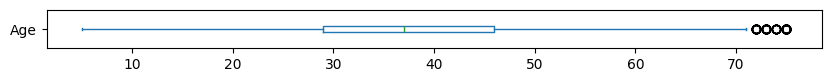

In [16]:
# extreme cases of age
plt.figure(figsize=(10, 0.5))
df.query('Age < 100')['Age'].plot(kind='box', vert=False)
plt.show()

In [17]:
filtered = df.query('Age > 71 & Age < 100')
out = pd.DataFrame({
    "count": filtered['Churned'].value_counts(normalize=True) * 100,
    "median_ltv": filtered.groupby('Churned')['Lifetime_Value'].median()
})

print('#customer with ', df['Age'].between(72, 100).sum())
print(out)

#customer with  106
             count  median_ltv
Churned                       
0        76.415094     1254.27
1        23.584906     1002.57


In [18]:
df['Lifetime_Value'].quantile(0.25)

np.float64(789.8175)

* Invalid cases will **drop** - low ltv and very few record.
* Extreme Age (excluding invalid) cases are nominal extreme with not major proportion customer leaving , but moderate ltv.

### Total_Purchases
invalid and extreme 

In [19]:
filtered = df.query('Total_Purchases < 0')
print('#invalid cases:', filtered.shape[0], "\n"
      "min valid case value:", df.query('Total_Purchases > 0')['Total_Purchases'].min(), "\n"
      "invalid cases churned proportion [0, 1]:", filtered['Churned'].value_counts().values, "\n"
      "median ltv of invalid cases:", filtered.groupby('Churned')['Lifetime_Value'].median().to_dict()
)

#invalid cases: 40 
min valid case value: 1.0 
invalid cases churned proportion [0, 1]: [33  7] 
median ltv of invalid cases: {0: 1289.6, 1: 1266.23}


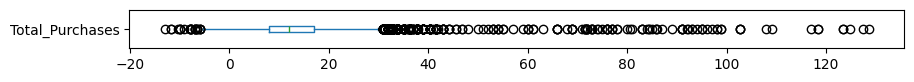

In [20]:
# extreme cases of total purchases
plt.figure(figsize=(10, 0.5))
df['Total_Purchases'].plot(kind='box', vert=False)
plt.show()

In [21]:
# extreme cases of total purchases
filtered = df.query('Total_Purchases > 30')
out = pd.DataFrame({
    "count": filtered['Churned'].value_counts(normalize=True) * 100,
    "median_ltv": filtered.groupby('Churned')['Lifetime_Value'].median()
})

print('#customer with many purchases', filtered.shape[0])
print(out)

#customer with many purchases 604
             count  median_ltv
Churned                       
0        77.649007     2716.27
1        22.350993     2775.26


* invalid cases - **flagged** - ltv is moderate even though few records.
* extreme cases — **Keep** — High-purchase customers are your best segment (high LTV, low churn). No action needed at this stage; transform can help non-tree models — defer to preprocessing.

### Lifetime_Value
Invalid and extreme case

In [22]:
print('#customer with zero ltv:', (df['Lifetime_Value'] <= 0).sum(), "\n"
      "min value after zero ltv:", df.query('Lifetime_Value > 0')['Lifetime_Value'].min(), "\n"
      "#customer will churn [0, 1]:", df.query('Lifetime_Value <= 0')['Churned'].value_counts().values
)

#customer with zero ltv: 9 
min value after zero ltv: 45.48 
#customer will churn [0, 1]: [8 1]


In [23]:
df.query('Lifetime_Value <= 0')[['Total_Purchases', 
                                 'Average_Order_Value', 
                                 'Days_Since_Last_Purchase', 
                                 'Returns_Rate']]

,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Returns_Rate
2198,0.0,68.26,28.0,4.4
15196,0.0,78.67,2.0,4.0
15794,0.0,194.75,13.0,15.2
23747,0.0,139.90,21.0,6.2
31584,0.0,58.74,1.0,11.3
32581,0.0,62.45,23.0,2.2
33939,0.0,46.65,0.0,12.8
38702,0.0,101.66,10.0,NaN
40098,0.0,124.49,20.0,1.2


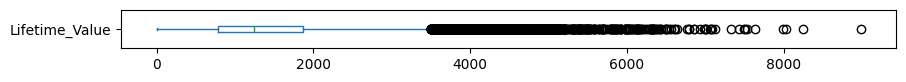

In [24]:
# extreme cases of ltv
plt.figure(figsize=(10, 0.5))
df['Lifetime_Value'].plot(kind='box', vert=False)
plt.show()

In [25]:
filtered = df.query('Lifetime_Value > 3500')
out = pd.DataFrame({
    "count": filtered['Churned'].value_counts(normalize=True) * 100,
    "median_ltv": filtered.groupby('Churned')['Lifetime_Value'].median()
})

print('#customer premium', filtered.shape[0])
print(out)

#customer premium 1685
             count  median_ltv
Churned                       
0        69.020772    4048.010
1        30.979228    4040.215


In [26]:
filtered = df.query('Lifetime_Value < 2000')
out = pd.DataFrame({
    "count": filtered['Churned'].value_counts(normalize=True) * 100,
    "median_ltv": filtered.groupby('Churned')['Lifetime_Value'].median()
})

print('#customer not premium:', filtered.shape[0])
print(out)

#customer not premium: 39263
             count  median_ltv
Churned                       
0        73.774291    1111.075
1        26.225709     787.610


Records with 0 LTF are invalid records, appearing along with 0 Total_Purchases. These records can be dropped, they're meaningless for the business.

Less proportion of premium customer are leaving however they're the ones with higher ltv. The model needs to be trained on ltv (predicted and/or known) ltv. Split will cause data hunger issue and limit data available for feature interaction.

* invalid case - **drop** - no ltv, no purchase, mostly staying. 

* extreme cases — **Keep** — Premium customers with high LTV. Preserve raw values as-is. This won't be directly used while inference, another model estimate the ltv, and churn model uses that value for inference. Cost-sensitive learning approach can help to penalise misclassifying high-LTV churners is a modeling decision — defer to modeling stage.

### Discount_Usage_Rate
Invalid case

In [27]:
filtered = df.query('Discount_Usage_Rate > 100')
print(
    "Discount_Usage_Rate feature properties \n"
    '#invalid cases:', filtered.shape[0], "\n"
    "max valid case value:", df.query('Discount_Usage_Rate <= 100')['Discount_Usage_Rate'].max(), "\n"
    "invalid cases churned proportion [0, 1]:", filtered['Churned'].value_counts().values, "\n"
    "median ltv of invalid cases:", filtered.groupby('Churned')['Lifetime_Value'].median().to_dict()
    )

Discount_Usage_Rate feature properties 
#invalid cases: 207 
max valid case value: 99.96 
invalid cases churned proportion [0, 1]: [147  60] 
median ltv of invalid cases: {0: 1311.48, 1: 1940.475}


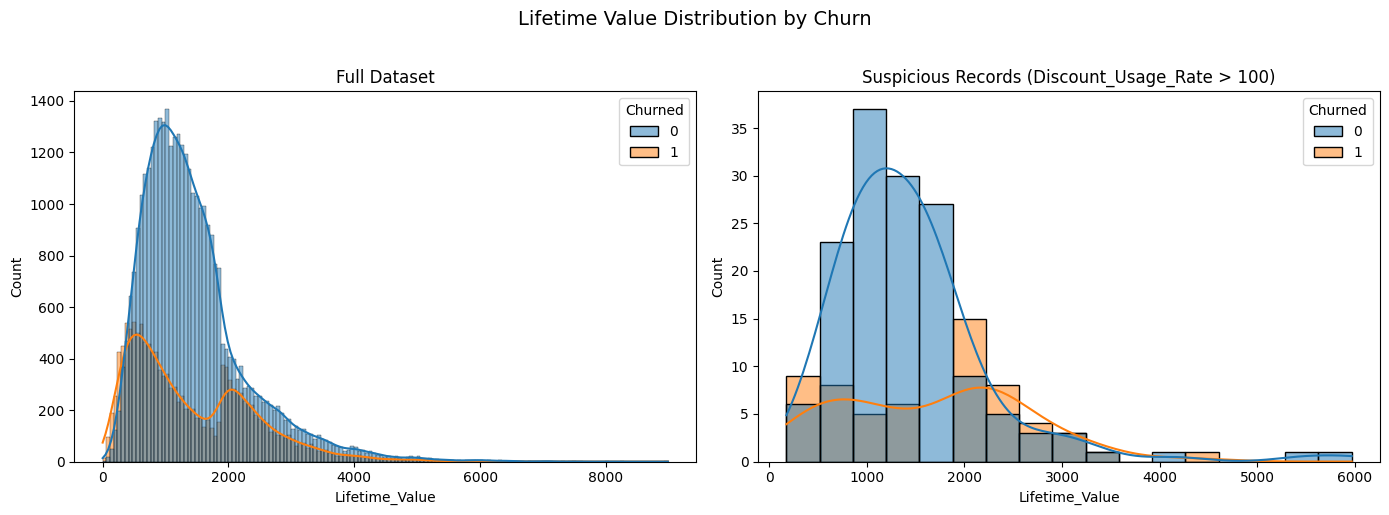

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

sns.histplot(df, kde=True, x='Lifetime_Value', hue='Churned', ax=axes[0])
axes[0].set_title('Full Dataset')

sns.histplot(df.query('Discount_Usage_Rate > 100'), kde=True, x='Lifetime_Value', hue='Churned', ax=axes[1])
axes[1].set_title('Suspicious Records (Discount_Usage_Rate > 100)')

plt.suptitle('Lifetime Value Distribution by Churn', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The 207 invalid `Discount_Usage_Rate` records will be **flagged** rather than dropped because:

- In the suspicious group, high-value customers show a notably higher churn concentration compared to the full dataset — suggesting these records may carry a real behavioral signal worth preserving.
- With an overall churn rate of ~30%, discarding any churned customer records risks losing high profile customers which business can't afford at this stage.

* invalid cases - **keep and flag** - 100+ percent order with discount usage is invalid but its coresponding to premium ltv. These invalid cases will flag.

### Days_Since_Last_Purchase
extreme cases

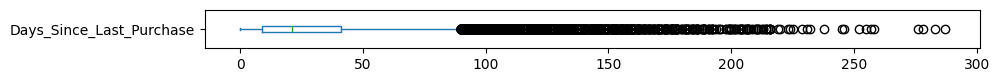

In [29]:
plt.figure(figsize=(10, 0.5))
df['Days_Since_Last_Purchase'].plot(kind='box', vert=False)
plt.show()

In [30]:
# extreme cases of days since last purchases 
filtered = df.query('Days_Since_Last_Purchase > 80')
out = pd.DataFrame({
    "count": filtered['Churned'].value_counts(normalize=True) * 100,
    "median_ltv": filtered.groupby('Churned')['Lifetime_Value'].median()
})

print('#customer with many purchases', filtered.shape[0])
print(out)

#customer with many purchases 3116
             count  median_ltv
Churned                       
0        51.604621    1443.705
1        48.395379    1003.150


* extreme cases - **keep as-is or transform** - The no of customers who are likely to churn for many days since last purchase is mostly balanced with moderate ltv. Can't assume all churned and intervene all to prevent churn - inefficient approach.

### Returns_Rate
extreme cases

In [31]:
df['Returns_Rate'].max()

np.float64(99.6157338622138)

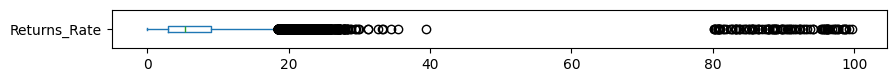

In [32]:
plt.figure(figsize=(10, 0.5))
df['Returns_Rate'].plot(kind='box', vert=False)
plt.show()

In [33]:
print('Churn distribution for return between 75-100')
pd.DataFrame({
    "#churn": df[df['Returns_Rate'].between(75, 100)]['Churned'].value_counts(),
    "ltv": df[df['Returns_Rate'].between(75, 100)].groupby('Churned')['Lifetime_Value'].median(),
})

Churn distribution for return between 75-100


,#churn,ltv
Churned,,
0,80,1283.975
1,20,1415.995


In [34]:
print('Churn distribution for return between 20-40')
pd.DataFrame({
    "count": df[df['Returns_Rate'].between(20, 40)]['Churned'].value_counts(),
    "ltv": df[df['Returns_Rate'].between(20, 40)].groupby('Churned')['Lifetime_Value'].median(),
})

Churn distribution for return between 20-40


,count,ltv
Churned,,
0,399,1355.02
1,283,1030.16


* extreme cases (75–100%) — **Keep** — ~20% churn but with high median LTV; dropping risks losing high-value churn signal. Retain all records. Transform only if using non-tree models — defer to preprocessing.

* extreme cases (20–40%) — **Keep** — Moderate churn proportion with no structural invalidity. No action needed at this stage; revisit during preprocessing based on model choice.

### Average_Order_Value
extreme cases

In [35]:
df['Average_Order_Value'].quantile(0.99)

np.float64(252.30010000000004)

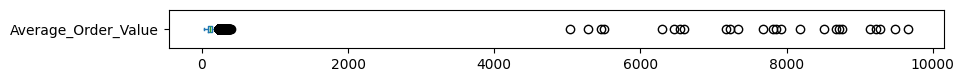

In [36]:
plt.figure(figsize=(10, 0.5))
df['Average_Order_Value'].plot(kind='box', vert=False)
plt.show()

In [37]:
# impact distribution of churned

print('Churn distribution for extreme (> 1000) avg order value in months')
pd.DataFrame({
    "#churn": df.query('Average_Order_Value > 1000')['Churned'].value_counts(),
    "ltv": df.query('Average_Order_Value > 1000').groupby('Churned')['Lifetime_Value'].median(),
})

Churn distribution for extreme (> 1000) avg order value in months


,#churn,ltv
Churned,,
0,17,1627.560
1,8,961.125


In [38]:
# find subsample anomaly threshold
df.query('Average_Order_Value < 1000').groupby('Churned')['Lifetime_Value'].median()

Churned
0    1266.56
1    1132.73
Name: Lifetime_Value, dtype: float64

In [39]:
print("#records:", df.shape[0], "\n"
      "#0.05% +ve extreme:", df['Average_Order_Value'].quantile(0.9995), "\n"
      "#extreme records:", (df['Average_Order_Value'] > 400).sum(), "\n"
      "kurtosis on full data:", df['Average_Order_Value'].kurt(), "\n"
      "kurstosis on data < 400:", df.query('Average_Order_Value < 400')['Average_Order_Value'].kurt()
      )

#records: 50000 
#0.05% +ve extreme: 400.17268572021504 
#extreme records: 25 
kurtosis on full data: 1959.9316791223796 
kurstosis on data < 400: 1.2117499573969273


 extreme cases — **Flag + Keep** — Outlier cluster is disjoint from the main distribution, not a continuous tail. Flag so the model can isolate this group directly. Transform will help non-tree models — defer to preprocessing.

---
## Cross-Column Relation

This section identifies invalid records where values across columns contradict each other logically.

### Membership_Years > Age
invalid case

In [40]:
df.query('Membership_Years > Age').shape

(5, 25)

In [41]:
filtered = df.query('Membership_Years > Age')

print(
    "#cases invalid:", df.query('Membership_Years > Age').shape[0], "\n"
    "churn proportion:", filtered['Churned'].value_counts().to_dict(), "\n", 
    "median ltv:", filtered.groupby('Churned')['Lifetime_Value'].median().to_dict()
    )

#cases invalid: 5 
churn proportion: {0: 3, 1: 2} 
 median ltv: {0: 1149.59, 1: 1480.59}


**Keep and flag** - even though invalid logic, but leaving customer have high ltv so this are kept as is with flag for invalid.

### High⬆ Pages_Per_Session & Low⬇ Session_Duration_Avg

In [42]:
# very high pages per session but 
high_pages = df["Pages_Per_Session"].quantile(0.9)
low_duration = df["Session_Duration_Avg"].quantile(0.1)

((df["Pages_Per_Session"] > high_pages) & 
 (df["Session_Duration_Avg"] < low_duration))\
     .sum()

np.int64(0)

### LTV formulation

In [43]:
df.query('Lifetime_Value < Total_Purchases * Average_Order_Value').shape

(31514, 25)

* `Lifetime_Value < Total_Purchases * Average_Order_Value` formulation: Lifetime_Value is probably a forecast and not direct historical value of customer. This aligns with descriptions provided by dataset publisher.

---

## Conclusion
Single-column invalids — create flag, retain record:

* Age (invalid > 100) — **Drop** — Logically impossible values. Low LTV, only 20 records (<0.04% of data). No meaningful signal to preserve — cost of retention outweighs any benefit.

* Lifetime_Value (invalid ≤ 0) — **Drop** — Zero LTV always co-occurs with zero purchases; these records carry no commercial meaning and add no predictive value.

* Total_Purchases (invalid < 0) — **Flag + Keep** — Negative purchase count is a data error, but the rest of the record remains usable. Flag as Flag_Purchases_Invalid so the model isolates this group before using the corrupted feature.

* Discount_Usage_Rate (invalid > 100%) — **Flag + Keep** — 197 records. Despite invalid values, this group shows higher churn among high‑LTV customers — a real behavioral signal. Flag as Flag_Discount_Rate_Invalid and retain.


Cross-column invalid — two fields corrupted:

* Membership_Years > Age (cross-column conflict) — **Flag + Keep** — Logically impossible, but these customers show high LTV and meaningful churn patterns. Flag as Flag_Membership_Age_Invalid so the model splits on the flag before touching corrupted fields.


Extreme but valid — transform to stabilise, preserve signal:

* Age (extreme 72–100) — **Keep As-Is** — Balanced churn and moderate LTV; no distortion risk.

* Total_Purchases (extreme > 30) — **Keep** — High-purchase customers are your best segment. No action at this stage; transform deferred to preprocessing based on model choice.

* Lifetime_Value (extreme > 3500) — **Keep** — Premium customers; preserve raw values. Cost-sensitive learning is a modeling decision — defer to modeling stage.

* Days_Since_Last_Purchase (extreme > 80 days) — **Keep** — Balanced churn, moderate LTV, no distortion risk. Transform deferred to preprocessing based on model choice.

* Returns_Rate (extreme 75–100%) — **Keep** — High median LTV among churners; retain all records. Transform deferred to preprocessing based on model choice.

* Average_Order_Value (extreme > 400, disjoint cluster) — **Flag + Keep** — Disjoint outlier cluster flagged as Flag_AOV_Extreme. Transform deferred to preprocessing based on model choice.

**Note:**
> Transforms are model-dependent; no harm for trees but required for non-tree models.

> Imputation strategy for flagged values is model-dependent — defer to preprocessing